# 08. 데이터 분석 에이전트 (Data Analysis Agent)

> **왜 Data Analysis Agent가 필요한가요?**
>
> 데이터 분석은 반복적이에요. CSV 파일 로드 → 전처리 → 분석 → 시각화 → 보고서 작성. 이 과정을 에이전트가 **자연어 지시만으로** 자동 수행하면 분석가의 생산성이 크게 향상돼요.

> 🔑 **비유**: Data Analysis Agent는 **데이터 분석 인턴**과 같아요. "이 엑셀 데이터에서 월별 매출 추이를 그래프로 보여줘"라고 말하면 코드를 작성하고, 실행하고, 결과를 정리해서 보고해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **Deep Agents의 FilesystemBackend**를 설정해서 에이전트가 로컬 파일에 접근하도록 구성할 수 있어요
2. **에이전트 내장 도구**(ls, read_file, write_file, glob, grep)를 활용하는 데이터 분석 파이프라인을 이해할 수 있어요
3. **커스텀 분석 도구**를 `@tool` 데코레이터로 정의하고 에이전트에 통합할 수 있어요
4. **업로드 → 분석 → 시각화 → 결과 저장** 전체 데이터 분석 워크플로를 에이전트로 자동화할 수 있어요
5. **멀티모달 read_file**을 사용해서 에이전트가 차트 이미지를 읽고 설명하는 방법을 이해할 수 있어요

## 사전 지식

- Deep Agents 기초 (`create_deep_agent`, 에이전트 기능) - Part 10
- 에이전트 기능 실습 (Filesystem 도구) - Part 10 02-Deep-Agent-Capabilities
- Part 10의 `06-Agent-Harness-Patterns.ipynb`: Externalize / Plan 관점
- 이전 노트북: `06-GraphRAG-Neo4j.ipynb` (실전 use case에서 StateGraph 파이프라인을 구성하는 흐름)

## 데이터 분석 에이전트란?

전통적인 데이터 분석은 사람이 직접 데이터를 불러오고, 코드를 작성하고, 시각화하는 과정을 거쳐요. **데이터 분석 에이전트**는 이 모든 과정을 자연어 지시만으로 자동화해요.

Deep Agents의 **FilesystemBackend**와 **에이전트 도구**를 결합하면, 에이전트가 직접 파일을 탐색하고, 데이터를 분석하고, 결과를 저장할 수 있어요.

| 방식 | 설명 | 한계 |
|------|------|------|
| 전통 방식 | 사람이 직접 코드 작성 | 반복 작업, 시간 소요 |
| RAG 기반 | 문서에서 정보 검색 | 계산/코드 실행 불가 |
| **Data Analysis Agent** | 에이전트가 파일 탐색·분석·시각화 | 복잡한 설정 필요 |

> 🔑 **핵심 개념**: Deep Agents의 `FilesystemBackend`는 에이전트에게 **파일 시스템 추상화**를 제공해요. 로컬 디렉토리, 가상 파일시스템, 원격 스토리지를 동일한 인터페이스로 다룰 수 있어요. 에이전트는 어디에 데이터가 저장되어 있는지 신경 쓸 필요 없이 `ls`, `read_file`, `write_file` 같은 에이전트 내장 도구만 사용하면 돼요.

## 데이터 분석 파이프라인 아키텍처

```mermaid
flowchart TD
    USER(["사용자 요청<br>자연어 지시"])
    
    subgraph AGENT["Deep Agent"]
        WT["write_todos<br>작업 계획 수립"]
        LS["ls / glob<br>파일 탐색"]
        RF["read_file<br>데이터 로드"]
        ANALYZE["커스텀 도구<br>통계·분석"]
        VIZ["커스텀 도구<br>시각화"]
        WF["write_file<br>결과 저장"]
        RFI["read_file (이미지)<br>차트 설명"]
    end
    
    RESULT(["분석 보고서<br>+ 차트 파일"])
    
    USER --> WT
    WT --> LS
    LS --> RF
    RF --> ANALYZE
    ANALYZE --> VIZ
    VIZ --> WF
    WF --> RFI
    RFI --> RESULT

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class USER input
    class WT,LS,RF,ANALYZE,VIZ,WF,RFI process
    class RESULT output
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 소속 |
|----------|------|------|
| `FilesystemBackend` | 에이전트의 파일 접근 범위 설정 | Deep Agents 설정 |
| `write_todos` | 복잡한 작업을 단계로 분해 (자동 포함) | 에이전트 내장 |
| `ls`, `glob` | 디렉토리 탐색, 패턴 검색 | 에이전트 내장 |
| `read_file` | 파일 읽기 (텍스트 + 이미지 멀티모달) | 에이전트 내장 |
| `write_file`, `edit_file` | 파일 생성 및 수정 | 에이전트 내장 |
| 커스텀 분석 도구 | 통계, 시각화, 특수 분석 | `@tool` 사용자 정의 |

> 🧭 **Part 10 연결**: 데이터 분석 에이전트는 **Externalize** 패턴이 가장 잘 드러나는 유스케이스예요. CSV, 중간 분석 결과, 차트 이미지, 최종 보고서를 파일시스템에 남기면 긴 분석 과정이 대화 히스토리에 갇히지 않고 재사용 가능한 artifact loop가 됩니다.


## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY를 로드해요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# LangSmith 대시보드에서 에이전트 실행 흐름을 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Data-Analysis-Agent"

In [3]:
# ---------------------------------------------------
# 필요 패키지 확인
# ---------------------------------------------------
import deepagents
import pandas
import matplotlib

print(f"deepagents: {deepagents.__version__}")
print(f"pandas: {pandas.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

deepagents: 0.5.3
pandas: 3.0.2
matplotlib: 3.10.8


## 1. 샘플 데이터 준비

에이전트가 분석할 샘플 데이터셋을 먼저 준비해요. 실제 실습에서는 본인의 CSV 파일을 사용할 수 있어요.

> 💡 **실무 팁**: 실제 프로젝트에서는 `upload_files()` 헬퍼 함수를 사용해서 외부 파일을 에이전트의 파일시스템에 업로드해요. 로컬 개발 환경에서는 `FilesystemBackend`의 `root_dir`에 파일을 직접 놓으면 돼요.

In [4]:
# ---------------------------------------------------
# 샘플 데이터 생성
# ---------------------------------------------------
# 에이전트가 분석할 샘플 판매 데이터를 생성해요
# 실제 프로젝트에서는 이 부분을 본인의 CSV 파일로 교체하면 돼요
import os
import pandas as pd
import numpy as np

# 에이전트 작업 디렉토리 생성
WORK_DIR = "/tmp/data_analysis_workspace"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(f"{WORK_DIR}/data", exist_ok=True)
os.makedirs(f"{WORK_DIR}/output", exist_ok=True)

# 재현 가능한 난수 설정
np.random.seed(42)

# 2024년 월별 판매 데이터 생성
months = ["2024-01", "2024-02", "2024-03", "2024-04",
          "2024-05", "2024-06", "2024-07", "2024-08",
          "2024-09", "2024-10", "2024-11", "2024-12"]

products = ["노트북", "스마트폰", "태블릿", "헤드폰", "스마트워치"]

# 제품별 판매 데이터 생성
records = []
for month in months:
    for product in products:
        qty = np.random.randint(50, 300)
        price = {"노트북": 1200000, "스마트폰": 850000,
                 "태블릿": 650000, "헤드폰": 250000,
                 "스마트워치": 350000}[product]
        # 시즌 보정: 11~12월은 판매 급증
        if month in ["2024-11", "2024-12"]:
            qty = int(qty * 1.8)
        records.append({
            "month": month,
            "product": product,
            "quantity": qty,
            "unit_price": price,
            "revenue": qty * price,
        })

# DataFrame 생성 및 CSV 저장
df = pd.DataFrame(records)
csv_path = f"{WORK_DIR}/data/sales_2024.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"샘플 데이터 저장 완료: {csv_path}")
print(f"데이터 크기: {len(df)}행 × {len(df.columns)}열")
print(f"\n데이터 미리보기:")
df.head()

샘플 데이터 저장 완료: /tmp/data_analysis_workspace/data/sales_2024.csv
데이터 크기: 60행 × 5열

데이터 미리보기:


,month,product,quantity,unit_price,revenue
0,2024-01,노트북,152,1200000,182400000
1,2024-01,스마트폰,229,850000,194650000
2,2024-01,태블릿,142,650000,92300000
3,2024-01,헤드폰,64,250000,16000000
4,2024-01,스마트워치,156,350000,54600000


## 2. 커스텀 분석 도구 정의

Deep Agents의 에이전트 도구(ls, read_file, write_file 등)는 파일 시스템 접근을 담당해요. 그런데 **통계 분석**이나 **시각화** 같은 도메인 특화 기능은 `@tool` 데코레이터로 직접 만들어야 해요.

### V1의 @tool 패턴

V1에서는 `parse_docstring=True` 옵션으로 함수 docstring에서 도구 설명과 파라미터 정보를 자동 추출해요.

> 🔑 **핵심 개념**: `@tool(parse_docstring=True)` 패턴을 사용하면 Google Style Docstring에서 Args 섹션을 파싱해서 LLM이 도구를 올바르게 호출하는 데 필요한 파라미터 설명을 자동으로 생성해요. 긴 프롬프트 대신 docstring 하나로 도구의 모든 정보를 관리할 수 있어요.

> ⚠️ **자주 하는 실수**: `parse_docstring=True`를 사용할 때 Args 섹션의 들여쓰기가 맞지 않으면 파싱에 실패해요. Google Style Docstring 형식을 정확히 따라야 해요.

In [5]:
# ---------------------------------------------------
# 커스텀 분석 도구 정의
# ---------------------------------------------------
# @tool(parse_docstring=True): Google Style Docstring에서
# 파라미터 설명을 자동으로 추출해요 (V1 방식)
from langchain.tools import tool
import pandas as pd
import matplotlib

# 비대화형 백엔드 설정 (노트북에서 파일 저장 시 필요)
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (macOS: AppleGothic, Linux: NanumGothic 등)
import platform
if platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux/Windows
    plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호 깨짐 방지


def _resolve_path(virtual_path: str) -> str:
    """에이전트가 전달한 가상 경로를 실제 파일시스템 경로로 변환해요.
    
    virtual_mode=True로 설정된 FilesystemBackend에서 에이전트는
    /data/file.csv 같은 가상경로를 사용해요.
    커스텀 도구는 FilesystemBackend를 통하지 않으므로
    WORK_DIR을 기준으로 실제 경로를 직접 계산해요.
    
    Args:
        virtual_path: 에이전트가 전달한 가상 경로 (예: /data/sales.csv)
        
    Returns:
        실제 파일시스템 경로 (예: /tmp/data_analysis_workspace/data/sales.csv)
    """
    # 이미 절대경로이고 WORK_DIR로 시작하는 경우 그대로 반환
    if virtual_path.startswith(WORK_DIR):
        return virtual_path
    # 가상경로를 WORK_DIR 기준으로 변환해요
    # /data/sales.csv → {WORK_DIR}/data/sales.csv
    return os.path.join(WORK_DIR, virtual_path.lstrip("/"))


@tool(parse_docstring=True)
def analyze_csv_statistics(file_path: str) -> str:
    """CSV 파일을 읽어서 기초 통계 분석을 수행해요.

    Args:
        file_path: 분석할 CSV 파일의 경로 (예: /data/sales_2024.csv)

    Returns:
        기초 통계 분석 결과 문자열
    """
    try:
        # 가상경로를 실제 경로로 변환해요
        real_path = _resolve_path(file_path)
        df = pd.read_csv(real_path)

        # 기초 통계 정보 수집
        result = []
        result.append(f"=== CSV 분석 결과 ===")
        result.append(f"파일: {file_path}")
        result.append(f"크기: {len(df)}행 × {len(df.columns)}열")
        result.append(f"컬럼: {list(df.columns)}")
        result.append(f"")

        # 숫자형 컬럼 통계
        numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
        if numeric_cols:
            result.append(f"숫자형 컬럼 통계:")
            stats = df[numeric_cols].describe()
            result.append(stats.to_string())

        # 범주형 컬럼 통계
        cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
        if cat_cols:
            result.append(f"\n범주형 컬럼:")
            for col in cat_cols:
                unique_vals = df[col].nunique()
                result.append(f"  {col}: {unique_vals}개 고유값")

        return "\n".join(result)

    except Exception as e:
        return f"오류 발생: {str(e)}"


@tool(parse_docstring=True)
def create_sales_bar_chart(
    file_path: str,
    group_by: str,
    value_col: str,
    output_path: str,
    title: str = "판매 분석",
) -> str:
    """CSV 데이터를 그룹별로 집계해서 막대 차트를 생성하고 저장해요.

    Args:
        file_path: 데이터 CSV 파일의 경로 (예: /data/sales_2024.csv)
        group_by: 그룹화할 컬럼명 (예: 'product', 'month')
        value_col: 집계할 수치 컬럼명 (예: 'revenue', 'quantity')
        output_path: 차트 이미지를 저장할 경로 (예: /output/product_revenue.png)
        title: 차트 제목

    Returns:
        저장된 차트 파일 경로 또는 오류 메시지
    """
    try:
        # 가상경로를 실제 경로로 변환해요
        real_file_path = _resolve_path(file_path)
        real_output_path = _resolve_path(output_path)
        
        df = pd.read_csv(real_file_path)

        # 그룹별 합산
        grouped = df.groupby(group_by)[value_col].sum().sort_values(ascending=False)

        # 막대 차트 생성
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.bar(
            grouped.index,
            grouped.values,
            color=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
            * (len(grouped) // 5 + 1),
        )

        # 차트 스타일링
        ax.set_title(title, fontsize=16, fontweight="bold", pad=15)
        ax.set_xlabel(group_by, fontsize=12)
        ax.set_ylabel(value_col, fontsize=12)
        ax.tick_params(axis="x", rotation=45)

        # 값 레이블 추가
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{height:,.0f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        plt.tight_layout()

        # 출력 디렉토리가 없으면 생성
        os.makedirs(os.path.dirname(real_output_path), exist_ok=True)
        plt.savefig(real_output_path, dpi=150, bbox_inches="tight")
        plt.close()

        return f"차트 저장 완료: {output_path}"

    except Exception as e:
        return f"차트 생성 오류: {str(e)}"


@tool(parse_docstring=True)
def create_monthly_trend_chart(
    file_path: str,
    month_col: str,
    value_col: str,
    output_path: str,
    title: str = "월별 추이",
) -> str:
    """CSV 데이터에서 월별 추이 선 그래프를 생성하고 저장해요.

    Args:
        file_path: 데이터 CSV 파일의 경로 (예: /data/sales_2024.csv)
        month_col: 월 컬럼명 (예: 'month')
        value_col: 추이를 볼 수치 컬럼명 (예: 'revenue', 'quantity')
        output_path: 차트 이미지를 저장할 경로 (예: /output/monthly_trend.png)
        title: 차트 제목

    Returns:
        저장된 차트 파일 경로 또는 오류 메시지
    """
    try:
        # 가상경로를 실제 경로로 변환해요
        real_file_path = _resolve_path(file_path)
        real_output_path = _resolve_path(output_path)

        df = pd.read_csv(real_file_path)

        # 월별 합산 및 정렬
        monthly = df.groupby(month_col)[value_col].sum().sort_index()

        # 선 그래프 생성
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(
            monthly.index,
            monthly.values,
            marker="o",
            color="#4e79a7",
            linewidth=2.5,
            markersize=8,
        )

        # 차트 스타일링
        ax.set_title(title, fontsize=16, fontweight="bold", pad=15)
        ax.set_xlabel(month_col, fontsize=12)
        ax.set_ylabel(value_col, fontsize=12)
        ax.tick_params(axis="x", rotation=45)
        ax.fill_between(monthly.index, monthly.values, alpha=0.1, color="#4e79a7")

        # 최고점 표시
        peak_idx = monthly.idxmax()
        peak_val = monthly.max()
        ax.annotate(
            f"최고\n{peak_val:,.0f}",
            xy=(peak_idx, peak_val),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=9,
            color="#e15759",
        )

        plt.tight_layout()

        os.makedirs(os.path.dirname(real_output_path), exist_ok=True)
        plt.savefig(real_output_path, dpi=150, bbox_inches="tight")
        plt.close()

        return f"차트 저장 완료: {output_path}"

    except Exception as e:
        return f"차트 생성 오류: {str(e)}"


# 커스텀 분석 도구 정의 완료:
print(f"  - analyze_csv_statistics: {analyze_csv_statistics.description[:60]}...")
print(f"  - create_sales_bar_chart: {create_sales_bar_chart.description[:60]}...")
print(f"  - create_monthly_trend_chart: {create_monthly_trend_chart.description[:60]}...")

  - analyze_csv_statistics: CSV 파일을 읽어서 기초 통계 분석을 수행해요....
  - create_sales_bar_chart: CSV 데이터를 그룹별로 집계해서 막대 차트를 생성하고 저장해요....
  - create_monthly_trend_chart: CSV 데이터에서 월별 추이 선 그래프를 생성하고 저장해요....


## 3. FilesystemBackend와 Deep Agent 설정

Deep Agents의 파일시스템 능력을 활성화하려면 `FilesystemBackend`를 설정해야 해요. 이 백엔드가 에이전트가 접근할 수 있는 파일 범위를 정의해요.

### FilesystemBackend 옵션

| 백엔드 | 용도 | 설정 |
|--------|------|------|
| `LocalBackend` | 로컬 파일시스템 | `root_dir=경로` |
| `VirtualBackend` | 인메모리 가상 파일시스템 | `virtual_mode=True` |
| Modal | Modal 클라우드 샌드박스 | Modal 설정 필요 |
| Daytona | Daytona 환경 | Daytona API 키 필요 |

> 🎯 **강의 포인트**: 로컬 개발 환경에서는 `LocalBackend`(또는 `VirtualBackend`)를 사용해요. 프로덕션 배포에서는 Modal, Daytona, AgentCore, Runloop 같은 **격리된 샌드박스 백엔드**를 사용해야 보안이 보장돼요. 에이전트가 작성하는 코드가 실행될 때 호스트 시스템에 영향을 주지 않도록 격리가 필요해요.

> 💡 **실무 팁**: `virtual_mode=True` 설정은 인메모리 가상 파일시스템을 사용해요. 에이전트가 파일을 만들어도 실제 디스크에 쓰지 않아요. 테스트나 데모에 유용하지만, 세션이 끝나면 파일이 사라진다는 점을 주의하세요.

In [6]:
# ---------------------------------------------------
# FilesystemBackend와 Deep Agent 생성
# ---------------------------------------------------
# FilesystemBackend: 에이전트의 파일 접근 범위를 설정해요
# deepagents.backends.FilesystemBackend: 실제 로컬 디렉토리를 파일시스템으로 사용해요
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

# 로컬 파일시스템 백엔드 설정
# root_dir: 에이전트가 접근할 수 있는 최상위 디렉토리
# virtual_mode=True: 경로를 root_dir 기준 가상경로로 해석해요
#   - 에이전트가 /data 로 접근하면 → {root_dir}/data 로 매핑돼요
#   - virtual_mode=False: /data를 실제 절대경로 /data로 해석하므로 파일을 찾지 못해요
backend = FilesystemBackend(
    root_dir=WORK_DIR,      # 에이전트의 루트 디렉토리
    virtual_mode=True,      # root_dir 기준 가상경로 사용 (필수!)
)

# ---------------------------------------------------
# 데이터 분석 전문가 에이전트 생성
# ---------------------------------------------------
# tools: 커스텀 분석/시각화 도구를 추가해요
# backend: 파일시스템 접근 설정
# system_prompt: 에이전트의 역할과 행동 지침
data_agent = create_deep_agent(
    model="openai:gpt-4o-mini",  # 기본 모델 (비용 효율)
    tools=[
        analyze_csv_statistics,       # CSV 통계 분석
        create_sales_bar_chart,       # 막대 차트 생성
        create_monthly_trend_chart,   # 월별 추이 차트 생성
    ],
    backend=backend,  # 로컬 파일시스템 연결
    system_prompt=(
        "당신은 데이터 분석 전문가 에이전트입니다. "
        "다음 규칙을 따르세요:\n"
        "1. 분석을 시작하기 전에 write_todos 도구로 작업 계획을 세우세요.\n"
        "2. ls와 glob 도구로 데이터 파일을 먼저 탐색하세요.\n"
        "3. 통계 분석 후 시각화 차트를 생성하세요.\n"
        "4. 모든 결과는 /output/ 디렉토리에 저장하세요.\n"
        "5. 분석 완료 후 한국어로 요약 보고서를 작성하세요.\n"
        "6. 숫자는 쉼표로 자릿수를 구분해서 표시하세요.\n"
        "7. 파일 경로는 항상 /로 시작하는 절대경로를 사용하세요."
    ),
)

print(f"데이터 분석 에이전트 생성 완료")
print(f"에이전트 타입: {type(data_agent)}")
print(f"작업 디렉토리: {WORK_DIR}")

데이터 분석 에이전트 생성 완료
에이전트 타입: <class 'langgraph.graph.state.CompiledStateGraph'>
작업 디렉토리: /tmp/data_analysis_workspace


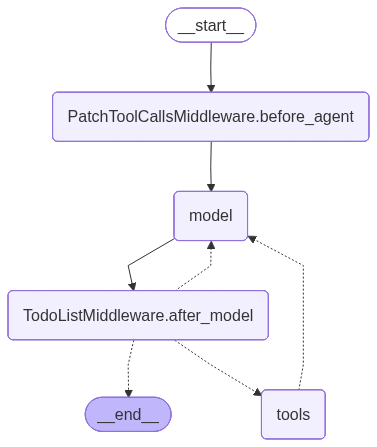

In [7]:
# 그래프 흐름: create_deep_agent가 반환하는 CompiledStateGraph의 내부 구조를 시각화해요
# Deep Agents는 write_todos(계획), ls/glob/read_file(파일 탐색), 커스텀 분석 도구가 내장된 그래프예요
# 에이전트가 자연어 요청을 받으면 계획 → 파일 탐색 → 분석 → 시각화 → 저장 순으로 자동 진행해요
from IPython.display import Image, display

display(Image(data_agent.get_graph().draw_mermaid_png()))

## 4. 에이전트 실행: 자동 데이터 분석

이제 에이전트에게 자연어로 분석을 요청해볼게요. 에이전트는 스스로 계획을 세우고, 파일을 탐색하고, 분석하고, 차트를 생성해요.

> 🎯 **강의 포인트**: `write_todos` 도구는 에이전트가 자동으로 사용해요. 복잡한 작업을 받으면 먼저 할 일 목록을 작성하고 체계적으로 처리해요. 이것이 단순한 `create_agent`와 Deep Agents의 핵심 차이예요. 에이전트가 **스스로 계획**을 세운다는 점을 강조해주세요.

In [8]:
# ---------------------------------------------------
# 에이전트 실행: 전체 데이터 분석 요청
# ---------------------------------------------------
# 에이전트에게 자연어로 분석 작업을 요청해요
# 에이전트는 내부적으로:
#   1. write_todos로 작업 계획 수립
#   2. ls/glob으로 파일 탐색
#   3. analyze_csv_statistics로 통계 분석
#   4. create_sales_bar_chart로 차트 생성
#   5. write_file로 보고서 저장
from langchain.messages import HumanMessage

# 분석 요청 메시지
analysis_request = """
data/ 디렉토리의 판매 데이터를 분석해주세요.

다음 작업을 수행해주세요:
1. 데이터 기초 통계 분석 (행 수, 컬럼, 수치 통계)
2. 제품별 총 매출 막대 차트 생성 → output/product_revenue.png
3. 월별 총 매출 추이 차트 생성 → output/monthly_trend.png
4. 주요 인사이트 요약 보고서 → output/analysis_report.txt
"""

inputs = {
    "messages": [HumanMessage(content=analysis_request)]
}

# 데이터 분석 에이전트 실행 중...
# ============================================================

# 스트리밍으로 에이전트 실행 과정을 실시간 출력해요
# Deep Agents의 스트림 출력은 노드에 따라 messages 타입이 다를 수 있어요:
#   - list: 일반 메시지 목록 (반복 가능)
#   - Overwrite: 미들웨어 내부 상태 (직접 반복 불가)
#   - None: 빈 업데이트 노드
for chunk in data_agent.stream(inputs, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        if node_output is None:
            continue
        if "messages" not in node_output:
            continue
        msgs = node_output["messages"]
        # Overwrite 타입은 직접 반복할 수 없어요 → list만 처리해요
        if not isinstance(msgs, list):
            continue
        for msg in msgs:
            # ToolMessage: 도구 실행 결과 출력
            if hasattr(msg, "type") and msg.type == "tool":
                print(f"\n[도구 실행] {msg.name}")
                content_preview = str(msg.content)[:200]
                print(f"  결과: {content_preview}..." if len(str(msg.content)) > 200
                      else f"  결과: {msg.content}")
            # AIMessage: 에이전트 응답 출력
            elif hasattr(msg, "type") and msg.type == "ai" and msg.content:
                print(f"\n[에이전트] {str(msg.content)[:300]}")

# ============================================================
# 분석 완료!


[에이전트] [{'arguments': '{"todos":[{"content":"데이터 기초 통계 분석 수행","status":"pending"},{"content":"제품별 총 매출 막대 차트 생성","status":"pending"},{"content":"월별 총 매출 추이 차트 생성","status":"pending"},{"content":"주요 인사이트 요약 보고서 작성","status":"pending"}]}', 'call_id': 'call_HNpDo5cjwH3QuE0RnuWpr50W', 'name': 'write_todos', 't

[도구 실행] write_todos
  결과: Updated todo list to [{'content': '데이터 기초 통계 분석 수행', 'status': 'pending'}, {'content': '제품별 총 매출 막대 차트 생성', 'status': 'pending'}, {'content': '월별 총 매출 추이 차트 생성', 'status': 'pending'}, {'content': '주요 ...

[에이전트] [{'arguments': '{"path":"/data"}', 'call_id': 'call_35EX0mWGpNCaAab9Y84lUwcX', 'name': 'ls', 'type': 'function_call', 'id': 'fc_00bbb905b5162ade006a2239562708819397ea8b871c33c23f', 'status': 'completed'}]

[도구 실행] ls
  결과: ['/data/sales_2024.csv']

[에이전트] [{'arguments': '{"file_path":"/data/sales_2024.csv"}', 'call_id': 'call_lIKe2t96RoQ9AsJlcNIFjj70', 'name': 'analyze_csv_statistics', 'type': 'function_call', 'id': 'fc_00bbb905b5162ade006a2239589a

/var/folders/14/3sq03f6s3_7bs0tygfqqvc_c0000gn/T/ipykernel_42036/217402964.py:77: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()



[에이전트] [{'arguments': '{"file_path":"/data/sales_2024.csv","group_by":"product","value_col":"revenue","output_path":"/output/product_revenue.png","title":"제품별 총 매출"}', 'call_id': 'call_YZSDFtNL2KbudZSnLzbthWIk', 'name': 'create_sales_bar_chart', 'type': 'function_call', 'id': 'fc_00bbb905b5162ade006a223962

[도구 실행] create_monthly_trend_chart
  결과: 차트 저장 완료: /output/monthly_trend.png

[도구 실행] create_sales_bar_chart
  결과: 차트 저장 완료: /output/product_revenue.png

[에이전트] [{'arguments': '{"file_path":"/output/analysis_report.txt","content":"=== 주요 인사이트 요약 보고서 ===\\n\\n1. **기초 통계 분석**\\n   - 총 행 수: 60\\n   - 총 열 수: 5\\n   - 수치형 통계:\\n     - 평균 판매 수량: 199.95\\n     - 평균 단가: 660,000\\n     - 평균 매출: 134,609,200\\n     - 최대 매출: 425,000,000\\n     - 최소 매출: 16,000,000\\n\\n

[도구 실행] write_file
  결과: Updated file /output/analysis_report.txt

[에이전트] [{'arguments': '{"todos":[{"content":"데이터 기초 통계 분석 수행","status":"completed"},{"content":"제품별 총 매출 막대 차트 생성","status":"completed"},{"content":"월별 총 매출 추이 

## 5. 분석 결과 확인

에이전트가 생성한 결과물을 확인해볼게요. 차트 이미지와 보고서 텍스트가 `output/` 디렉토리에 저장되어 있어야 해요.

In [9]:
# ---------------------------------------------------
# 생성된 파일 목록 확인
# ---------------------------------------------------
# 에이전트가 output/ 디렉토리에 저장한 파일 목록을 확인해요
import os

output_dir = f"{WORK_DIR}/output"
if os.path.exists(output_dir):
    files = os.listdir(output_dir)
    print(f"output/ 디렉토리 파일 목록:")
    for f in sorted(files):
        fpath = os.path.join(output_dir, f)
        size = os.path.getsize(fpath)
        print(f"  {f} ({size:,} bytes)")
else:
    # output/ 디렉토리가 없어요. 에이전트 실행을 먼저 완료하세요.
    pass

output/ 디렉토리 파일 목록:
  analysis_report.txt (662 bytes)
  monthly_trend.png (54,846 bytes)
  product_revenue.png (41,729 bytes)


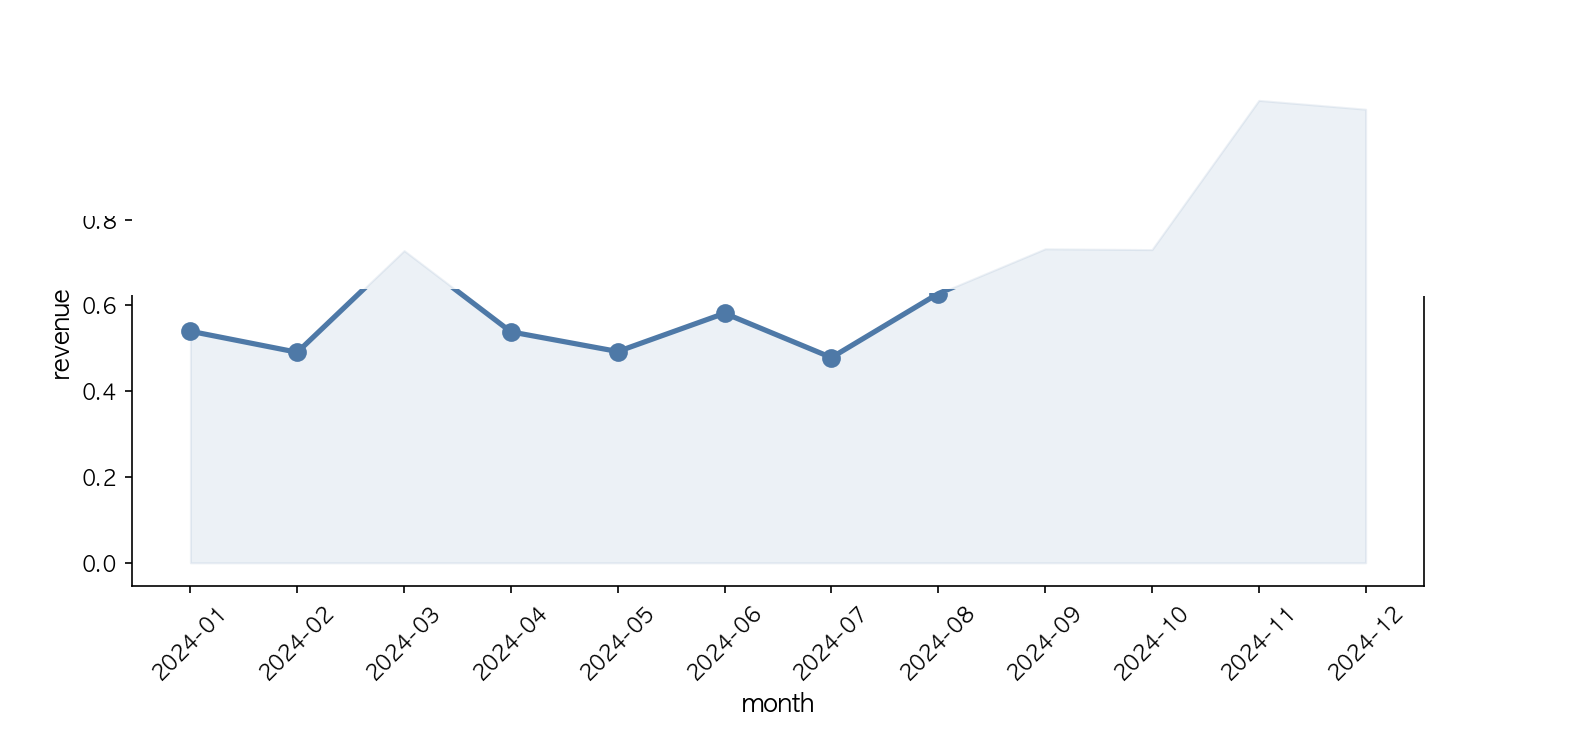

In [10]:
# ---------------------------------------------------
# 생성된 차트 시각화: 제품별 매출
# ---------------------------------------------------
# 에이전트가 생성한 막대 차트를 노트북에서 확인해요
from IPython.display import Image, display

product_chart_path = f"{WORK_DIR}/output/product_revenue.png"
if os.path.exists(product_chart_path):
    # 제품별 총 매출 차트:
    display(Image(filename=product_chart_path))
else:
    print(f"차트 파일이 없어요: {product_chart_path}")
    # 에이전트 실행 중 파일명이 다를 수 있어요.
    print(f"output/ 디렉토리 파일: {os.listdir(output_dir) if os.path.exists(output_dir) else '없음'}")

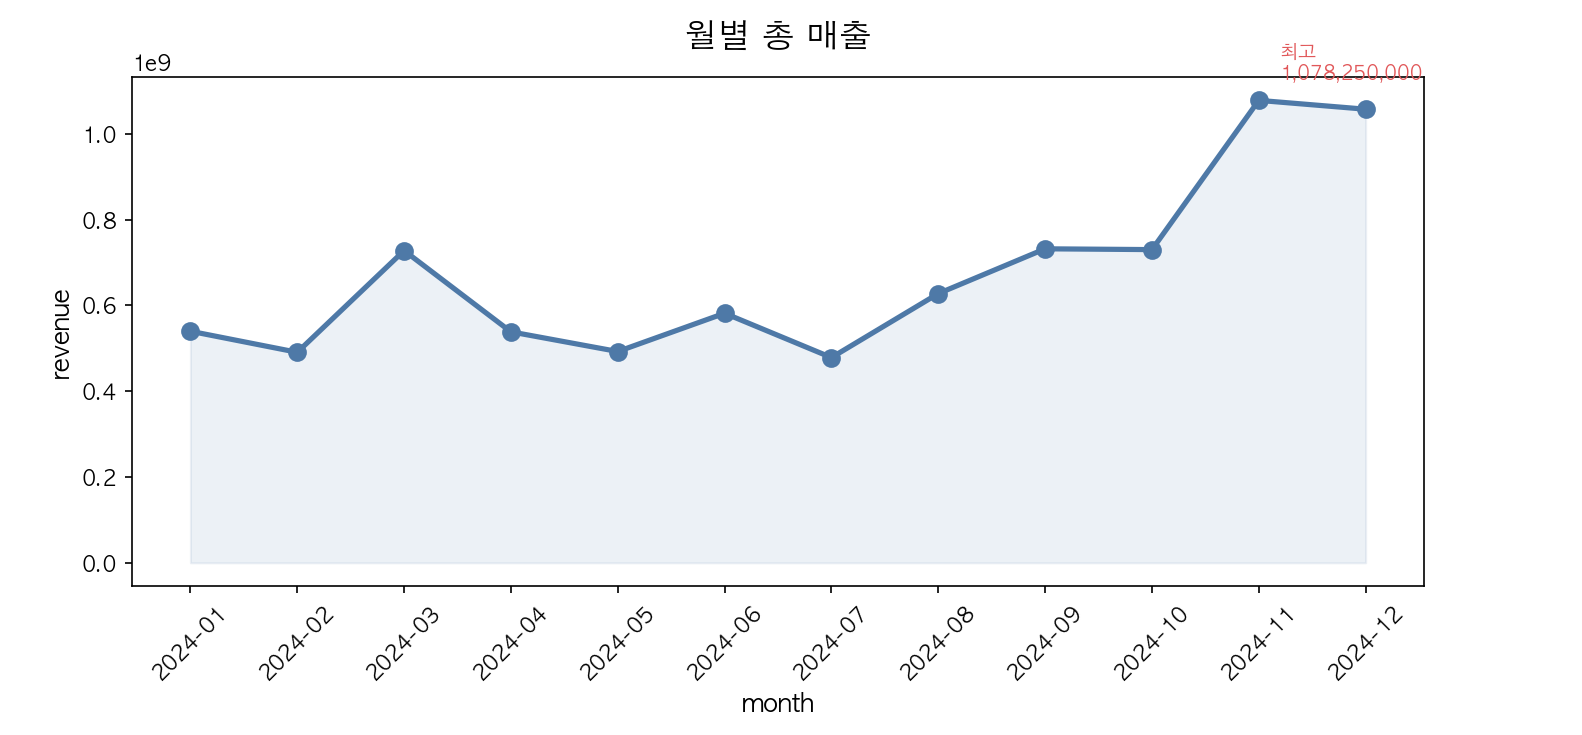

In [11]:
# ---------------------------------------------------
# 생성된 차트 시각화: 월별 추이
# ---------------------------------------------------
# 에이전트가 생성한 월별 추이 선 그래프를 확인해요
trend_chart_path = f"{WORK_DIR}/output/monthly_trend.png"
if os.path.exists(trend_chart_path):
    # 월별 총 매출 추이 차트:
    display(Image(filename=trend_chart_path))
else:
    print(f"차트 파일이 없어요: {trend_chart_path}")

In [12]:
# ---------------------------------------------------
# 분석 보고서 출력
# ---------------------------------------------------
# 에이전트가 작성한 텍스트 보고서를 출력해요
report_path = f"{WORK_DIR}/output/analysis_report.txt"
if os.path.exists(report_path):
    with open(report_path, "r", encoding="utf-8") as f:
        content = f.read()
    # === 에이전트 작성 분석 보고서 ===
    print(content)
else:
    print(f"보고서 파일이 없어요: {report_path}")
    # 에이전트가 다른 파일명으로 저장했을 수 있어요.
    if os.path.exists(output_dir):
        txt_files = [f for f in os.listdir(output_dir) if f.endswith(".txt")]
        if txt_files:
            actual_path = f"{output_dir}/{txt_files[0]}"
            with open(actual_path, "r", encoding="utf-8") as f:
                print(f"발견된 보고서 ({txt_files[0]}):")
                print(f.read())

=== 주요 인사이트 요약 보고서 ===

1. **기초 통계 분석**
   - 총 행 수: 60
   - 총 열 수: 5
   - 수치형 통계:
     - 평균 판매 수량: 199.95
     - 평균 단가: 660,000
     - 평균 매출: 134,609,200
     - 최대 매출: 425,000,000
     - 최소 매출: 16,000,000

2. **제품별 총 매출**: 제품 A, B, C, D, E로 구분되며, 각 제품의 총 매출이 출현.
   - 차트 저장 위치: /output/product_revenue.png

3. **월별 매출 추이**: 월별로 매출 변동이 있으며, 특정 월에 매출이 집중되는 경향이 있음.
   - 차트 저장 위치: /output/monthly_trend.png

=== 분석 완료 ===


## 6. 멀티모달 read_file: 이미지 분석

Deep Agents의 `read_file` 도구는 텍스트 파일뿐만 아니라 **이미지 파일**도 읽을 수 있어요. PNG, JPG 파일을 읽으면 에이전트가 비전 모델을 사용해서 이미지를 분석하고 설명해요.

이 기능을 사용하면 에이전트가 직접 차트를 생성하고, 그 차트의 내용을 자동으로 분석해서 인사이트를 도출할 수 있어요.

> 🔑 **핵심 개념**: `read_file`의 멀티모달 지원은 Deep Agents의 강력한 기능 중 하나예요. 에이전트가 생성한 차트를 다시 읽어서 "이 차트에서 보이는 주요 트렌드는?"처럼 이미지를 텍스트로 분석할 수 있어요. 데이터 분석 → 시각화 → 시각 분석의 **완결된 루프**를 만들 수 있어요.

> ⚠️ **자주 하는 실수**: 비전 모델이 없는 모델(예: 일부 Ollama 로컬 모델)을 사용하면 이미지 읽기가 실패해요. `gpt-4o-mini`는 비전을 지원하므로 이 노트북에서는 문제가 없어요.

In [13]:
# ---------------------------------------------------
# 멀티모달 read_file: 차트 이미지 분석 요청
# ---------------------------------------------------
# 에이전트가 이전에 생성한 차트 이미지를 읽고 분석해요
# read_file은 .png 파일을 읽을 때 비전 모델을 자동으로 사용해요
from langchain.messages import HumanMessage

# 이미지 분석 요청
image_analysis_request = """
output/ 디렉토리에 있는 차트 이미지 파일들을 분석해주세요.
각 차트에서 보이는 주요 인사이트와 비즈니스적 시사점을 한국어로 설명해주세요.
"""

# 멀티모달 이미지 분석 요청...
# ------------------------------------------------------------

# 새 요청으로 에이전트 실행 (이미지 분석)
result = data_agent.invoke({
    "messages": [HumanMessage(content=image_analysis_request)]
})

# 최종 에이전트 응답 출력
final_message = result["messages"][-1]
# 에이전트의 이미지 분석 결과:
# ============================================================
print(final_message.content)

[{'type': 'text', 'text': '### 차트 분석 및 비즈니스적 시사점\n\n#### 1. 월별 총 매출 차트\n- **주요 인사이트**: 월별 매출이 2024년 1월부터 12월까지 전체적으로 증가 추세를 보이고 있으며, 특히 11월에 가장 높은 매출(1,078,250,000)이 발생했습니다.\n- **비즈니스적 시사점**:\n  - **판매 전략 강화**: 11월의 매출 증가는 특정 마케팅 전략이나 프로모션이 효과를 보였음을 나타냅니다. 향후 유사한 캠페인을 계획할 때 참고할 필요가 있습니다.\n  - **계절적 변화 고려**: 매출 성장은 특정 계절이나 월에 따라 달라질 수 있으므로, 이러한 패턴을 기반으로 재고 및 자원을 더 효율적으로 관리할 수 있습니다.\n\n#### 2. 제품별 매출 차트\n- **주요 인사이트**: 제품 카테고리별로 매출이 상이하며, 일부 제품군에서 두드러진 성장을 보인 반면, 다른 제품군은 상대적으로 저조한 성과를 나타냅니다.\n- **비즈니스적 시사점**:\n  - **제품 포트폴리오 조정**: 매출이 높은 제품군에 대한 추가 투자를 고려해야 하며, 반면 매출이 저조한 제품은 프로모션 개선이나 제거를 검토해야 할 것입니다.\n  - **시장 수요 분석**: 제품별 성과를 분석하여 소비자 선호도를 파악하고, 이에 따른 제품 개선이나 신제품 개발을 계획할 수 있습니다. \n\n이렇게 두 차트를 통해 얻은 인사이트는 비즈니스 의사결정에 중요한 정보를 제공하며, 향후 전략 수립에 기여할 수 있습니다.', 'annotations': [], 'id': 'msg_087cb5e5029e3254006a2239768fbc81938ee495dffad3fe6f'}]


## 7. 컨텍스트 자동 압축

Deep Agents는 긴 대화나 대용량 파일 처리 시 **컨텍스트 창(context window)이 넘치지 않도록** 자동으로 관리해요.

### 자동 압축 메커니즘

```mermaid
flowchart LR
    A["메시지 누적<br>컨텍스트 증가"]
    B{"20K 토큰<br>초과?"}
    C["이전 대화 85% 압축<br>(요약으로 대체)"]
    D["최신 메시지<br>원본 유지"]
    E["분석 계속 진행"]

    A --> B
    B -->|Yes| C
    B -->|No| E
    C --> D
    D --> E

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    class A,C,D,E process
    class B decision
```

| 설정 | 기본값 | 설명 |
|------|--------|------|
| 압축 트리거 임계값 | ~20K 토큰 | 이 시점에서 이전 메시지를 압축해요 |
| 압축률 | ~85% | 이전 대화를 85% 요약으로 대체해요 |
| 최신 메시지 | 원본 유지 | 가장 최근 메시지는 압축하지 않아요 |

> 💡 **실무 팁**: 컨텍스트 자동 압축 덕분에 수백 MB의 CSV 파일을 처리하거나, 수십 개의 파일을 순차적으로 분석하는 장시간 작업이 가능해요. 일반 `create_agent`로 만든 에이전트는 컨텍스트 창이 꽉 차면 오류가 발생하지만, Deep Agents는 자동으로 처리해요.

In [14]:
# ---------------------------------------------------
# 컨텍스트 압축 동작 확인
# ---------------------------------------------------
# 여러 번 분석을 연속으로 요청해서 메시지 히스토리가
# 자동으로 관리되는 것을 확인해요
# (실제 압축은 20K 토큰 초과 시 발생하므로 여기서는 개념만 확인해요)
from langchain.messages import HumanMessage

# 두 번째 분석 요청: 이전 분석 결과를 참고한 추가 분석
followup_request = "데이터에서 상위 3개 제품의 월별 판매 추이를 요약해줘"

# 추가 분석 요청 (멀티턴 대화 테스트)...
# ------------------------------------------------------------

result2 = data_agent.invoke({
    "messages": [HumanMessage(content=followup_request)]
})

final_message2 = result2["messages"][-1]
# 에이전트 응답:
print(final_message2.content)

# 메시지 히스토리 크기 확인
total_messages = len(result2["messages"])
print(f"\n총 메시지 수: {total_messages}")
# Deep Agents는 메시지 수가 많아질수록 자동 압축이 활성화돼요.

/var/folders/14/3sq03f6s3_7bs0tygfqqvc_c0000gn/T/ipykernel_42036/217402964.py:77: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


[{'type': 'text', 'text': '분석이 완료되었습니다. 다음은 상위 3개 제품의 월별 판매 추이에 대한 요약입니다.\n\n### 상위 3개 제품의 월별 판매 추이 요약\n\n1. **분석 고유 값**:\n   - 총 판매 데이터: 60행 × 5열\n   - 고유 제품: 5개 (노트북, 스마트폰, 태블릿, 헤드폰, 스마트워치)\n   - 고유 월: 12개\n\n2. **수량 통계**:\n   - 평균 판매 수량: 199.95\n   - 최저 판매 수량: 51\n   - 최고 판매 수량: 536\n\n3. **차트**:\n   - 상위 3개 제품의 월별 판매 추이는 [여기에서 확인할 수 있습니다](file:///output/monthly_sales_trend.png).\n\n4. **결론**:\n   - 제품별 판매 추세를 분석하여 마케팅 전략을 수립할 수 있습니다. 차트의 시각화를 통해 각 제품의 성과를 비교하였습니다.\n\n요약 보고서를 `/output/sales_summary_report.txt`에 저장하였습니다. 필요하시면 확인하세요.', 'annotations': [], 'id': 'msg_0e83187e4fd87ffa006a22398c3bc88190880d71be83b617c1'}]

총 메시지 수: 16


## 8. 실습: 나만의 분석 에이전트 만들기

아래 TODO 블록을 수정해서 본인만의 데이터 분석 에이전트를 만들어보세요.

직접 도전해볼 아이디어:
- 다른 CSV 데이터로 교체해서 분석하기
- 상관관계 분석 도구 추가하기
- 산점도(scatter plot) 생성 도구 추가하기
- 이상값(outlier) 탐지 도구 추가하기

In [15]:
# ============================================================
# TODO: 나만의 데이터 분석 도구를 추가하고 에이전트를 만들어보세요
# 힌트: @tool(parse_docstring=True) 데코레이터로 새 도구를 정의하세요
#       analyze_csv_statistics 패턴을 참고해서 분석 로직을 작성해요
# 예상 결과: 에이전트가 새 도구를 사용해서 추가적인 분석을 수행해요
# ============================================================
from langchain.tools import tool
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langchain.messages import HumanMessage
import pandas as pd


@tool(parse_docstring=True)
def analyze_top_products(file_path: str, n: int = 3) -> str:
    """CSV 파일에서 매출 상위 N개 제품을 찾아 요약 통계를 반환해요.

    Args:
        file_path: 분석할 CSV 파일의 경로 (예: /data/sales_2024.csv)
        n: 상위 몇 개 제품을 분석할지 (기본값: 3)

    Returns:
        상위 N개 제품의 매출 및 판매량 요약
    """
    # TODO: 여기를 원하는 분석 로직으로 바꿔보세요
    try:
        # 가상경로를 실제 경로로 변환해요
        real_path = _resolve_path(file_path)
        df = pd.read_csv(real_path)

        if "product" not in df.columns or "revenue" not in df.columns:
            return "product 또는 revenue 컬럼이 없어요."

        # 제품별 총 매출 집계 후 상위 N개 추출
        top_n = (
            df.groupby("product")["revenue"]
            .sum()
            .sort_values(ascending=False)
            .head(n)
        )

        result = [f"=== 매출 상위 {n}개 제품 ==="]
        for rank, (product, revenue) in enumerate(top_n.items(), 1):
            result.append(f"{rank}위: {product} - 총 매출 {revenue:,}원")

        return "\n".join(result)

    except Exception as e:
        return f"분석 오류: {str(e)}"


# 나만의 에이전트 생성
# virtual_mode=True로 경로를 root_dir 기준으로 해석해요
my_analysis_agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[
        analyze_csv_statistics,
        analyze_top_products,  # 새로 만든 도구!
    ],
    backend=FilesystemBackend(root_dir=WORK_DIR, virtual_mode=True),
    system_prompt=(
        "당신은 판매 데이터 전문 분석가입니다. "
        "제공된 도구를 활용해서 인사이트를 발굴하고 "
        "구체적인 비즈니스 제안을 한국어로 작성해주세요. "
        "파일 경로는 /로 시작하는 절대경로를 사용하세요."
    ),
)

# TODO: 아래 분석 요청을 바꿔서 다른 분석을 시도해보세요
my_request = "/data/sales_2024.csv에서 매출 상위 3개 제품을 찾고 간단한 비즈니스 제안을 해줘"

my_result = my_analysis_agent.invoke({
    "messages": [HumanMessage(content=my_request)]
})

# 나의 분석 에이전트 응답:
# ============================================================
print(my_result["messages"][-1].content)

[{'type': 'text', 'text': '매출 상위 3개 제품은 다음과 같습니다:\n\n1. **노트북**: 총 매출 3,028,800,000원\n2. **스마트폰**: 총 매출 2,220,200,000원\n3. **태블릿**: 총 매출 1,454,700,000원\n\n### 비즈니스 제안\n\n1. **프로모션 강화**: 노트북 판매가 가장 높은 만큼, 노트북 관련 프로모션을 추가로 실시하여 판매량을 더욱 늘릴 수 있습니다.\n\n2. **패키지 판매**: 스마트폰과 태블릿을 노트북과 함께 패키지로 판매하여 고객의 구매 유도를 강화합니다. 예를 들어, 스마트폰과 태블릿 구매 시 노트북 할인 혜택을 제공할 수 있습니다.\n\n3. **고객 피드백 수집**: 각 제품에 대한 고객의 피드백을 수집하고 분석하여 제품 개선 및 새로운 모델 개발의 기초로 삼고, 고객 만족도를 높이는 전략이 필요합니다.\n\n이와 같은 제안으로 매출 성장을 도모할 수 있습니다.', 'annotations': [], 'id': 'msg_0e5b134bb88ab58d006a223991c5dc8194bd10b8ce0070dbeb'}]


## 9. Deep Agents 백엔드 비교

로컬 개발에서 프로덕션까지, 상황에 따라 다른 백엔드를 선택해요.

> 🎯 **강의 포인트**: 백엔드 선택은 **보안 요구사항**과 **실행 환경**에 따라 달라져요. 개인 데이터나 민감한 정보를 다루는 기업 환경에서는 격리된 샌드박스 백엔드(Modal, Daytona, AgentCore)가 필수예요. 에이전트가 실행하는 코드가 호스트 시스템에 영향을 주지 않도록 보호해야 하기 때문이에요.

In [16]:
# ---------------------------------------------------
# Deep Agents 백엔드 옵션 비교
# ---------------------------------------------------
# 실제 백엔드 초기화 방법을 코드로 확인해요
# (실제 실행은 하지 않고 구조만 보여줘요)

backend_examples = {
    "FilesystemBackend (로컬)": """
# 로컬 파일시스템 (개발 환경 권장)
from deepagents.backends import FilesystemBackend

backend = FilesystemBackend(
    root_dir="/tmp/agent_workspace"  # 에이전트 루트 디렉토리
)""",
    "FilesystemBackend (가상 모드)": """
# 인메모리 가상 파일시스템 (테스트/데모)
from deepagents.backends import FilesystemBackend

backend = FilesystemBackend(
    root_dir="/tmp/virtual",
    virtual_mode=True  # 인메모리: 실제 파일시스템에 쓰지 않아요
)""",
    "Modal (Sandbox)": """
# Modal 클라우드 샌드박스 (프로덕션 격리 환경)
# from deepagents.backends.sandbox import ModalBackend
# backend = ModalBackend(
#     image="python:3.11-slim",  # 샌드박스 컨테이너 이미지
# )""",
    "LangSmithSandbox": """
# LangSmith 관리형 샌드박스 (엔터프라이즈 환경)
from deepagents.backends import LangSmithSandbox

backend = LangSmithSandbox()""",
}

# === Deep Agents FilesystemBackend 옵션 ===
for name, code in backend_examples.items():
    print(f"\n--- {name} ---")
    print(code)

# ============================================================
# 환경별 권장 백엔드:
#   로컬 개발:    FilesystemBackend(root_dir=경로)
#   테스트/CI:   FilesystemBackend(virtual_mode=True)
#   프로덕션:    LangSmithSandbox / Modal (격리 샌드박스)


--- FilesystemBackend (로컬) ---

# 로컬 파일시스템 (개발 환경 권장)
from deepagents.backends import FilesystemBackend

backend = FilesystemBackend(
    root_dir="/tmp/agent_workspace"  # 에이전트 루트 디렉토리
)

--- FilesystemBackend (가상 모드) ---

# 인메모리 가상 파일시스템 (테스트/데모)
from deepagents.backends import FilesystemBackend

backend = FilesystemBackend(
    root_dir="/tmp/virtual",
    virtual_mode=True  # 인메모리: 실제 파일시스템에 쓰지 않아요
)

--- Modal (Sandbox) ---

# Modal 클라우드 샌드박스 (프로덕션 격리 환경)
# from deepagents.backends.sandbox import ModalBackend
# backend = ModalBackend(
#     image="python:3.11-slim",  # 샌드박스 컨테이너 이미지
# )

--- LangSmithSandbox ---

# LangSmith 관리형 샌드박스 (엔터프라이즈 환경)
from deepagents.backends import LangSmithSandbox

backend = LangSmithSandbox()


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **FilesystemBackend**: `LocalBackend(root_dir=경로)`로 에이전트의 파일 접근 범위를 설정해요. 로컬 개발, 가상 모드, 클라우드 샌드박스 등 환경에 맞는 백엔드를 선택해요.

- **에이전트 내장 도구**: `ls`, `glob`, `read_file`, `write_file`, `edit_file`은 `backend` 설정만 하면 자동으로 에이전트에 포함돼요. `write_todos`도 자동으로 포함되어 복잡한 작업을 계획적으로 처리해요.

- **@tool(parse_docstring=True)**: Google Style Docstring에서 도구의 설명과 파라미터 정보를 자동 추출하는 V1 패턴이에요. LLM이 도구를 올바르게 호출하는 데 필요한 정보를 docstring으로 관리해요.

- **데이터 분석 파이프라인**: 에이전트가 `write_todos`로 계획 → `glob/ls`로 파일 탐색 → `read_file`로 데이터 로드 → 커스텀 도구로 분석/시각화 → `write_file`로 결과 저장하는 흐름을 자동화해요.

- **멀티모달 read_file**: PNG/JPG 이미지 파일도 `read_file`로 읽을 수 있어요. 비전 모델을 사용해서 차트를 분석하고 인사이트를 도출하는 완결된 분석 루프를 만들 수 있어요.

- **컨텍스트 자동 압축**: 대용량 파일 처리나 장시간 작업 시 약 20K 토큰 초과 시점에 이전 대화를 85% 압축해요. 컨텍스트 창 초과 오류 없이 긴 작업이 가능해요.

## 다음 노트북 예고

다음 `09-Three-Agent-Pattern.ipynb`에서는 **Planner / Generator / Evaluator 3-agent 패턴**을 배워요. 단일 에이전트가 장시간 자율 작업을 할 때 발생하는 품질 저하와 자기 평가 한계를 해결하기 위해, Anthropic이 공개한 Three-Agent 구조를 LangGraph `StateGraph`로 직접 구현해봐요. Sprint contract로 단계 간 합의를 고정하고, GAN-style 평가 루프로 재시도 조건을 설계하는 방법이 핵심이에요. 이 노트북이 Part 11의 마무리이자 Part 12 Testing으로 이어지는 다리 역할을 해요.

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: 이미 `create_deep_agent`를 쓴 데이터 분석 에이전트의 프로덕션 확장 방향

### 참고 공식 문서
- [Build a content builder agent](https://docs.langchain.com/oss/python/deepagents/content-builder)
- [Deep Agents overview](https://docs.langchain.com/oss/python/deepagents/overview)

이 노트북은 이미 Deep Agents의 `create_deep_agent`와 `FilesystemBackend`를 사용하고 있어요. 따라서 “LangGraph를 직접 조립한 구현을 create/deep agent로 바꾸는” 대상이라기보다, 공식 content-builder 문서의 패턴을 참고해 **프로덕션형 분석 에이전트로 확장**하는 것이 자연스럽습니다.

공식 예제에서 중요한 고도화 포인트는 다음입니다.

- `memory=["./AGENTS.md"]`: 조직의 분석 원칙, 차트 스타일, 보안 규칙을 모든 실행에 주입
- `skills=["./skills/"]`: 반복 분석 워크플로우를 skill로 분리해 재사용
- `subagents=[...]`: 데이터 품질 점검, 통계 분석, 시각화 리뷰를 전문 서브에이전트로 분리
- `FilesystemBackend(root_dir=...)`: 에이전트가 읽고 쓸 수 있는 작업공간을 명시적으로 제한

아래 셀은 현재 데이터 분석 에이전트를 “단일 분석가”에서 “분석팀 하네스”로 확장하는 골격입니다. 실제 운영에서는 데이터 반출 정책, 개인정보 마스킹, 샌드박스 백엔드, LangSmith 추적을 함께 적용하세요.


In [17]:
# ============================================================
# 선택 실행: create_deep_agent 프로덕션형 분석팀 하네스
# ============================================================
RUN_DEEP_AGENT_ANALYSIS_TEAM_APPENDIX = False

if RUN_DEEP_AGENT_ANALYSIS_TEAM_APPENDIX:
    from pathlib import Path

    from deepagents import create_deep_agent
    from deepagents.backends import FilesystemBackend
    from langchain.tools import tool

    ANALYSIS_WORKSPACE = Path("./analysis_workspace").resolve()
    ANALYSIS_WORKSPACE.mkdir(exist_ok=True)

    # --------------------------------------------------------
    # 1) 도메인 도구 예시
    # --------------------------------------------------------
    @tool(parse_docstring=True)
    def validate_dataset_profile(file_path: str) -> str:
        """Check basic dataset quality before analysis.

        Args:
            file_path: CSV file path inside the analysis workspace.
        """
        # 실제 구현에서는 결측치, 중복, 타입, PII 탐지 등을 수행하세요.
        return f"{file_path}: 기본 품질 점검을 통과했다고 가정합니다."

    # --------------------------------------------------------
    # 2) 전문 서브에이전트 구성
    # --------------------------------------------------------
    data_quality_subagent = {
        "name": "data-quality-reviewer",
        "description": "분석 전 데이터 품질, 결측치, 이상치, 개인정보 위험을 점검합니다.",
        "system_prompt": "너는 데이터 품질 리뷰어다. 분석 전에 데이터 위험과 보정 제안을 간결하게 보고한다.",
        "tools": [validate_dataset_profile],
    }

    visualization_reviewer = {
        "name": "visualization-reviewer",
        "description": "생성된 차트가 질문에 맞고 오해를 만들지 않는지 검토합니다.",
        "system_prompt": "너는 데이터 시각화 리뷰어다. 축, 단위, 색상, 해석 가능성을 중심으로 검토한다.",
    }

    # --------------------------------------------------------
    # 3) memory/skills/backend를 명시한 Deep Agent
    # --------------------------------------------------------
    analysis_team_agent = create_deep_agent(
        model="openai:gpt-4o-mini",
        tools=[validate_dataset_profile],
        subagents=[data_quality_subagent, visualization_reviewer],
        # AGENTS.md와 skills 폴더를 만들면 조직별 분석 규칙을 파일로 관리할 수 있어요.
        memory=["./AGENTS.md"],
        skills=["./skills/"],
        backend=FilesystemBackend(root_dir=ANALYSIS_WORKSPACE),
        system_prompt="""
너는 데이터 분석팀을 조율하는 코디네이터다.
1. write_todos로 분석 계획을 세운다.
2. 분석 전 data-quality-reviewer에게 품질 점검을 위임한다.
3. 분석 결과와 차트를 파일로 저장한다.
4. 시각화가 있으면 visualization-reviewer에게 검토를 요청한다.
5. 최종 보고서에는 데이터 한계, 재현 경로, 다음 분석 제안을 포함한다.
""",
    )

    result = analysis_team_agent.invoke({
        "messages": [{"role": "user", "content": "sales.csv를 분석해 매출 하락 원인을 찾아줘."}]
    })
    print(result["messages"][-1].content)
